<a href="https://colab.research.google.com/github/layan3000/lab1/blob/main/AI342Lab1_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AI342-F1/Lab-Tutoral/blob/main/AI342Lab1.ipynb)

# Lab 1: Introduction to Digital Images and Image Processing with Python
**Course:** AI342 Image Processing  
**University:** Taibah University  
**College:** Computer Science and Engineering  
**Department:** AI & DS
---
### Learning Objectives:
* Represent a digital image as a numerical array.
* Understand pixels, spatial resolution, and grey level intensity.
* Load, display, and inspect images in Python.
* Apply simple low-level image processing operations.
* Relate practical operations to the image processing pipeline introduced in Chapter 1

## 1. Environment Setup

In [15]:
# write your code here
import numpy as np
import matplotlib.pyplot as plt



## 2. What is a digital image in practice?
In the lecture, a digital image is defined as a two dimensional function $f(x,y)$ where the value at each coordinate represents intensity. In practice, this function is stored as a matrix of numbers.

##**Exercise 2.1: Create a synthetic image**


In [16]:
# Task: Create an 8x8 black image (matrix of zeros)
# Hint: Use np.zeros((rows, cols))
image = np.zeros((8, 8))
print(image)

# --- Discussion Questions ---
# 1. What is the spatial resolution of this image? 8x8 pixel
# 2. What does each value represent? gray level of intensity

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


##**Exercise 2.2: Visualise the image**

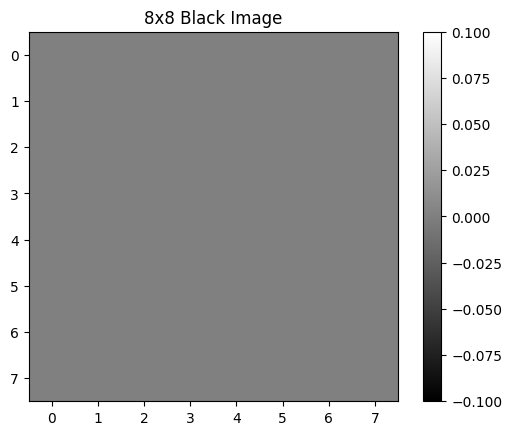

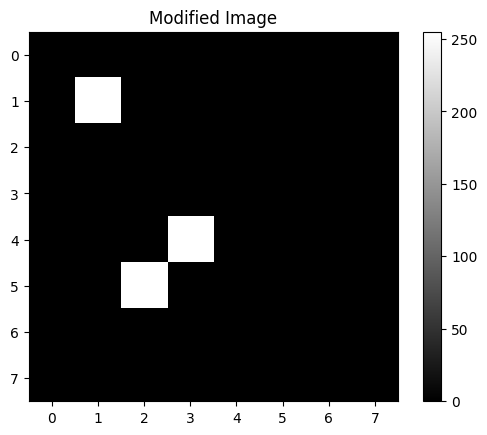

In [17]:
# write your code here
plt.imshow(image, cmap='gray')
plt.title("8x8 Black Image")
plt.colorbar()
plt.show()
# Task: Change some pixels to 255 (White) and re-visualize
# image[row, col] = 255
# WRITE YOUR CODE HERE:
image[4, 3] = 255
image[5, 2] = 255
image[1, 1] = 255

plt.imshow(image, cmap='gray')
plt.title("Modified Image")
plt.colorbar()
plt.show()


## 3. Pixels and intensity values
Pixels are the smallest units of a digital image and hold quantised intensity values, as discussed in the slides on pixels and digitisation
## **Exercise 3.1: Modify individual pixels**


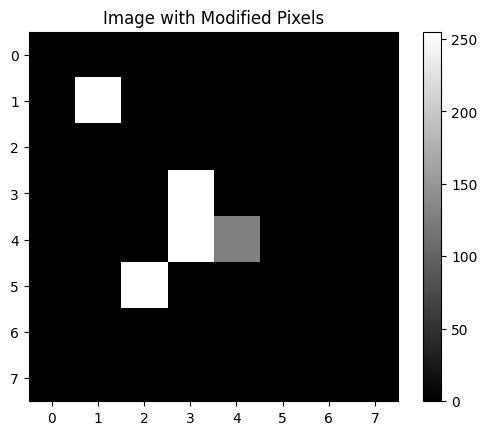

In [18]:
# write your code here
image[3, 3] = 255
image[4, 4] = 128
plt.imshow(image, cmap='gray')
plt.title("Image with Modified Pixels")
plt.colorbar()
plt.show()

#Questions
#1.	Which pixel is brighter and why? image[3, 3] pixel is the brighter 225=white
#2.	How does quantisation affect visual appearance?
#quantisation reduces number of gray level when gray level is fewer the visible loss
#smooth transition make it less realistic


## 4. Grey scale images
The course focuses primarily on grey scale images with one sample per pixel.
## **Exercise 4.1: Generate a gradient image**


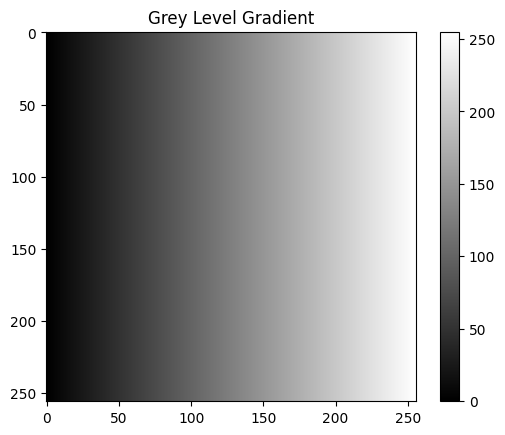

In [19]:
# write your code here
gradient = np.tile(np.linspace(0, 255, 256), (256, 1))
plt.imshow(gradient, cmap='gray')
plt.title("Grey Level Gradient")
plt.colorbar()
plt.show()

#Questions
#1.	How many grey levels are visible? 256 grey levels (0–255)
#2.	What data type is used to store the pixel values? 8-bit unsigned integer (uint8)


## 5. Image acquisition and representation
Image acquisition converts a physical scene into a digital image. In Python, loading an image is equivalent to acquiring an already digitised scene.
## **Exercise 5.1: Load and inspect an image**

(1352, 1500, 3)
uint8


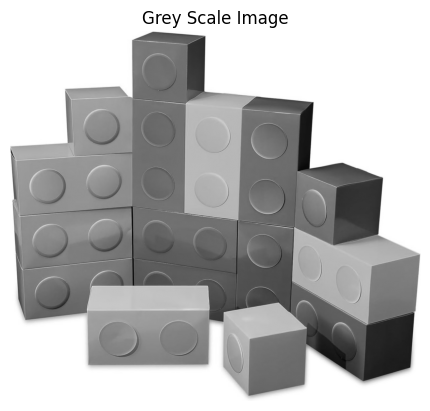

In [6]:
# write your code here
import matplotlib.pyplot as plt
from matplotlib.image import imread

image =imread('61BKoUgWlcL._AC_SL1500_.jpg')

print(image.shape)
print(image.dtype)

gray = image.mean(axis=2)

plt.imshow(gray, cmap='gray')
plt.title("Grey Scale Image")
plt.axis('off')
plt.show()

## 6. Low level image processing: image in, image out
Low level processing improves visual quality without extracting semantic meaning, as described in the lecture pipeline
## **Exercise 6.1: Image enhancement by contrast stretching**

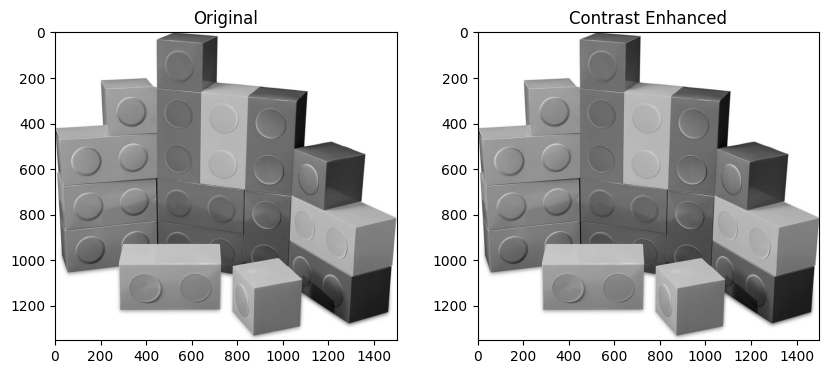

In [7]:
# write your code here
min_val = gray.min()
max_val = gray.max()
enhanced = (gray - min_val) / (max_val - min_val) * 255
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.subplot(1,2,2)
plt.imshow(enhanced, cmap='gray')
plt.title("Contrast Enhanced")
plt.show()
#Questions
#1.	Which image has better visibility of details? the enhanced image details is clear
#2.	Is this enhancement subjective or objective? subjective depends on human perception


## 7. Noise and image restoration
Noise removal is a core example of low level processing.

## **Exercise 7.1: Add artificial noise**

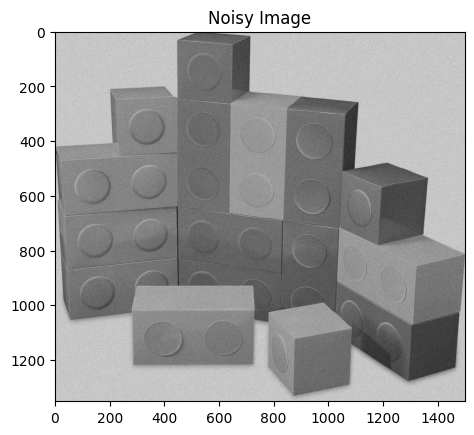

In [8]:
# write your code here
noise = np.random.normal(0, 20, gray.shape)
noisy = gray + noise
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.show()

## **Exercise 7.2: Simple smoothing filter**

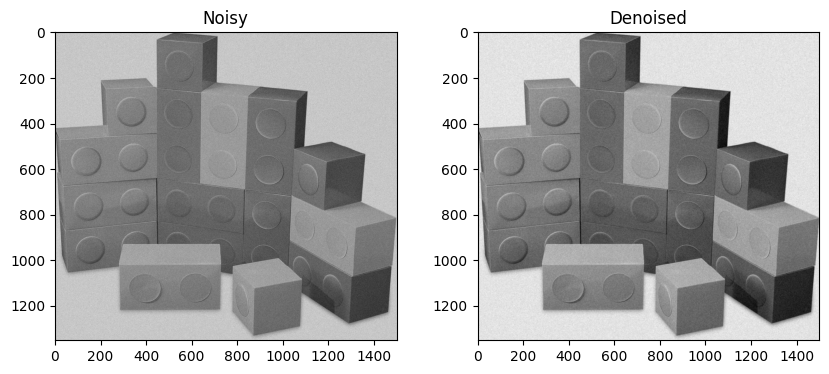

In [9]:
def mean_filter(img, k=3):
    pad = k // 2
    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            output[i, j] = padded[i:i+k, j:j+k].mean()
    return output

# complete the code here
denoised = mean_filter(noisy)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")
plt.subplot(1,2,2)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised")
plt.show()

## 8. From image processing to image analysis
The lecture distinguishes between low, mid, and high level processing.
## **Exercise 8.1: Simple threshold segmentation**

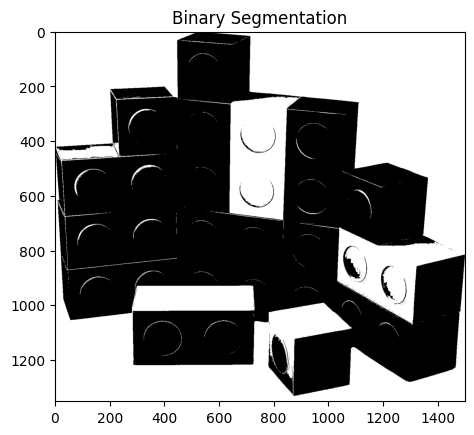

In [10]:
## write your code here
threshold = gray.mean()
binary = gray > threshold
plt.imshow(binary, cmap='gray')
plt.title("Binary Segmentation")
plt.show()

# Discussion:
# 1. Is this segmentation reliable? not always because the sensitive to noise and it depends on threshold value
# 2. What information is lost when converting to binary ?all grey level intensity information

## 9. Mini project: connecting theory to practice
The lecture distinguishes between low, mid, and high level processing.
## **Task 9.1: Create a synthetic image containing at least two objects**

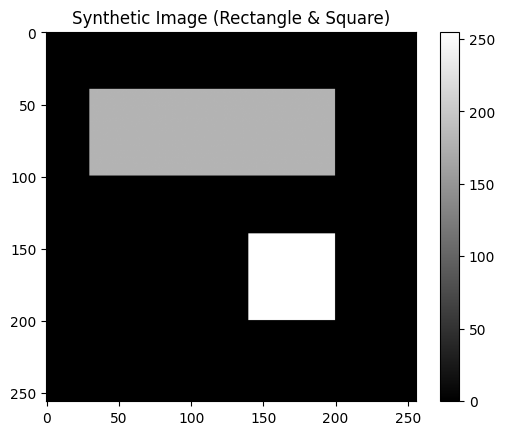

In [11]:

image = np.zeros((256, 256))

# rectangle
image[40:100, 30:200] = 180

# square
image[140:200, 140:200] = 255

plt.imshow(image, cmap='gray')
plt.title("Synthetic Image (Rectangle & Square)")
plt.colorbar()
plt.show()

## **Task 9.2: Add noise to the imager**

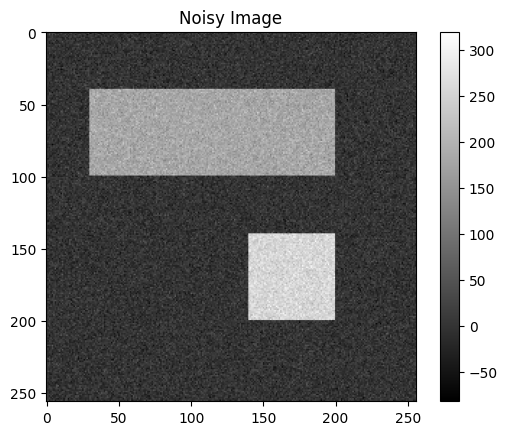

In [12]:
noise = np.random.normal(0, 20, image.shape)
noisy = image + noise

plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.colorbar()
plt.show()

## **Task 9.3: Apply enhancement and denoising**

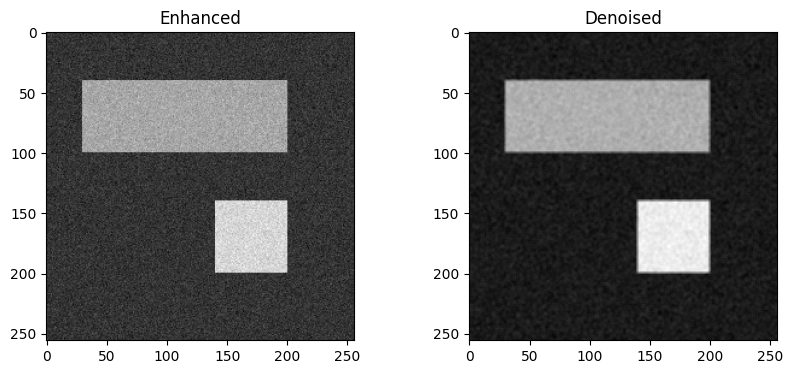

In [13]:
min_val = noisy.min()
max_val = noisy.max()
enhanced = (noisy - min_val) / (max_val - min_val) * 255
def mean_filter(img, k=3):
    pad = k // 2
    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            output[i, j] = padded[i:i+k, j:j+k].mean()
    return output

denoised = mean_filter(enhanced)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")

plt.subplot(1,2,2)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised")
plt.show()

## **Task 9.4: Segment the objects using a threshold**

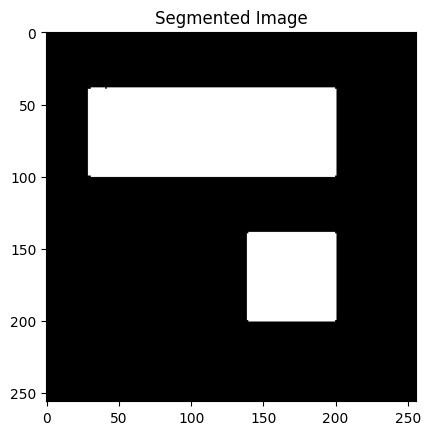

In [14]:
threshold = denoised.mean()
segmented = denoised > threshold

plt.imshow(segmented, cmap='gray')
plt.title("Segmented Image")
plt.show()

#**9. Mini project: connecting theory to practice**

**Task**

Using only NumPy and Matplotlib:

1.	Create a synthetic image containing at least two objects

2.	Add noise to the image

3.	Apply enhancement and denoising

4.	Segment the objects using a threshold

**Deliverables**

•	Code

•	Output images

•	Short explanation mapping each step to the image processing stages shown in the Chapter 1 pipeline diagram


***Note: Organize your project into logical steps using separate cells, include a Text Cell before each stage to explain your approach, and ensure all results are clearly visualized using titles and subplots***

Create synthetic imag  Image Acquisition

Add noise	Image Acquisition

Contrast enhancement	Image Enhancement
Noise filtering	Image Restoration
Thresholding	Segmentation
Morphological cleanup	Morphological Processing
Feature extraction	Representation & Description
Classification (if applied)	Object Recognition